<a href="https://colab.research.google.com/github/Rut092/End-to-End-AI-Roadmap/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [12]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, [0,1]].values
y = dataset.iloc[:, -1].values

print(X,y)

[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    28  79000]
 [    22  1800

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

* **Model Limitations**: Gaussian Naive Bayes assumes features are strictly independent and follow a normal distribution. If the data doesn't fit this, algorithms like Logistic Regression, SVM, or Random Forest might work better.

* **Skewed Probabilities**: The model gets "distracted" by the large numbers and mistakenly thinks Salary is exponentially more important than Age just because the numbers are wider.

* The Fix: StandardScaler forces every feature to have a mean of 0 and a standard deviation of 1. This normalizes the scale, forcing the model to value Age and Salary equally when calculating probabilities.


In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [16]:
print(cm)

[[65  3]
 [ 7 25]]


In [18]:
classifier.predict([[30, 87000]])

array([0])

In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [22]:
print(X_train)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

In [20]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [21]:
cm2 = confusion_matrix(y_test, y_pred)
print(cm2)

[[65  3]
 [ 7 25]]


Generated Code for plotting of Graph

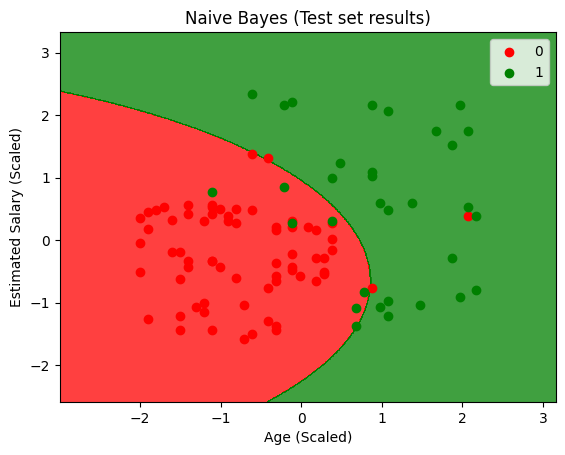

In [28]:
from matplotlib.colors import ListedColormap

# Create a meshgrid for the Age and Estimated Salary features
# Use the combined range of X_train and X_test for broader visualization
X_combined = np.vstack((X_train, X_test))
X1, X2 = np.meshgrid(np.arange(start = X_combined[:, 0].min() - 1, stop = X_combined[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_combined[:, 1].min() - 1, stop = X_combined[:, 1].max() + 1, step = 0.01))

# Predict the class for each point in the meshgrid
# FIX: Removed redundant sc.transform() as X1, X2 are already in the scaled domain
Z = gnb.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)
plt.contourf(X1, X2, Z,
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

# Set the limits for the plot
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Define colors for scatter plot to avoid UserWarning
colors = ListedColormap(('red', 'green'))

# Plot the actual data points from the test set
for i, j in enumerate(np.unique(y_test)):
    # FIX: Used 'color' keyword argument to avoid UserWarning
    plt.scatter(X_test[y_test == j, 0], X_test[y_test == j, 1],
                color = colors(i), label = j)

plt.title('Naive Bayes (Test set results)')
plt.xlabel('Age (Scaled)') # Added (Scaled) for clarity
plt.ylabel('Estimated Salary (Scaled)') # Added (Scaled) for clarity
plt.legend()
plt.show()